Building a dataset


In [1]:
import json
from pathlib import Path
import pandas as pd

In [5]:
INPUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_segments")
OUTPUT_PATH = Path("/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_dataset.csv")

In [3]:
def flatten_importance_files(input_dir: Path):
    rows = []

    for json_path in sorted(input_dir.glob("*.json")):
        conversation_id = json_path.stem  # filename without .json

        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        segments = data.get("segments", [])

        for idx, seg in enumerate(segments):
            text = seg.get("text", "").strip()
            importance = seg.get("importance", None)

            # Skip invalid entries explicitly
            if importance is None or text == "":
                continue

            rows.append({
                "conversation_id": conversation_id,
                "segment_id": idx,
                "text": text,
                "importance": int(importance),
                "speaker": seg.get("speaker", "UNKNOWN"),
                "start": seg.get("start"),
                "end": seg.get("end"),
            })

    return pd.DataFrame(rows)


In [6]:
df = flatten_importance_files(INPUT_DIR)

print(f"Total segments: {len(df)}")
print("Class distribution:")
print(df["importance"].value_counts(normalize=True))

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved dataset to {OUTPUT_PATH}")

Total segments: 545
Class distribution:
importance
1    0.710092
0    0.289908
Name: proportion, dtype: float64
Saved dataset to /content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_dataset.csv


Dataset splitting

In [4]:
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_dataset.csv")

#Load
df = pd.read_csv(DATA_PATH)

GROUP_COL = "conversation_id"   # meeting id column
LABEL_COL = "importance"        # 0/1 label
TEXT_COL  = "text"              # text input

# a group-wise split (no leakage across meetings)
train_meetings = [
    "meeting01_importance_score",
    "meeting02_importance_score",
    "meeting03_importance_score",
    "meeting04_importance_score",
    "meeting05_importance_score",
]
val_meetings = ["meeting07_importance_score"]   # short meeting -> good for tuning
test_meetings = ["meeting06_importance_score"]  # politics holdout

allowed = set(train_meetings + val_meetings + test_meetings)
present = set(df[GROUP_COL].unique())
missing = allowed - present
extra = present - allowed

if missing:
    raise ValueError(f"These meetings were not found in the dataset: {sorted(missing)}")
if extra:
    # not fatal
    print(f"Warning: dataset contains meetings not included in split lists: {sorted(extra)}")

def assign_split(meeting_id: str) -> str:
    if meeting_id in train_meetings:
        return "train"
    if meeting_id in val_meetings:
        return "val"
    if meeting_id in test_meetings:
        return "test"
    return "unused"

df["split"] = df[GROUP_COL].map(assign_split)

# Keep only used splits
df = df[df["split"].isin(["train", "val", "test"])].copy()

# Basic integrity checks
assert df[TEXT_COL].notna().all(), "Found missing text values"
assert df[LABEL_COL].isin([0, 1]).all(), "Labels must be 0/1"
for s in ["train", "val", "test"]:
    assert (df["split"] == s).any(), f"Split {s} ended up empty"

#Report distribution per split
def report(split_name: str):
    sub = df[df["split"] == split_name]
    print(f"\n== {split_name.upper()} ==")
    print("meetings:", sorted(sub[GROUP_COL].unique()))
    print("rows:", len(sub))
    print("label distribution:\n", sub[LABEL_COL].value_counts(normalize=True).rename("proportion"))



In [5]:
report("train")
report("val")
report("test")


== TRAIN ==
meetings: ['meeting01_importance_score', 'meeting02_importance_score', 'meeting03_importance_score', 'meeting04_importance_score', 'meeting05_importance_score']
rows: 412
label distribution:
 importance
1    0.652913
0    0.347087
Name: proportion, dtype: float64

== VAL ==
meetings: ['meeting07_importance_score']
rows: 41
label distribution:
 importance
1    0.731707
0    0.268293
Name: proportion, dtype: float64

== TEST ==
meetings: ['meeting06_importance_score']
rows: 92
label distribution:
 importance
1    0.956522
0    0.043478
Name: proportion, dtype: float64


In [6]:
# Save
out_dir = Path("/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits")
out_dir.mkdir(parents=True, exist_ok=True)

df[df["split"]=="train"].to_csv(out_dir / "train.csv", index=False)
df[df["split"]=="val"].to_csv(out_dir / "val.csv", index=False)
df[df["split"]=="test"].to_csv(out_dir / "test.csv", index=False)

print(f"\nSaved splits to: {out_dir}")



Saved splits to: /content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits


Turn each split into a model-ready dataset with the chosen input format: input_text = prev_text + " [SEP] " + text + " [SEP] " + next_text

In [7]:
SPLIT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits")
TRAIN_PATH = Path("/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits/train.csv")
VAL_PATH = Path("/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits/val.csv")
TEST_PATH  = Path("/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits/test.csv")

# ---- Adjust these names to match your CSV header exactly ----
GROUP_COL  = "conversation_id"   # meeting id / file id
ORDER_COL  = "start"             # for chronological ordering within meeting
SPEAKER_COL= "speaker"
TEXT_COL   = "text"
LABEL_COL  = "importance"

def fmt_turn(speaker, text):
    speaker = str(speaker).strip()
    text = str(text).strip()
    return f"[{speaker}] {text}"


def add_context_columns(df: pd.DataFrame) -> pd.DataFrame:
    # safety: ensure no NaNs in text/speaker
    df[SPEAKER_COL] = df[SPEAKER_COL].fillna("")
    df[TEXT_COL] = df[TEXT_COL].fillna("")

    # sort inside each meeting
    df = df.sort_values([GROUP_COL, ORDER_COL]).reset_index(drop=True)

    # shift for prev/next inside each meeting
    df["prev_speaker"] = df.groupby(GROUP_COL)[SPEAKER_COL].shift(1).fillna("")
    df["prev_text"]    = df.groupby(GROUP_COL)[TEXT_COL].shift(1).fillna("")
    df["next_speaker"] = df.groupby(GROUP_COL)[SPEAKER_COL].shift(-1).fillna("")
    df["next_text"]    = df.groupby(GROUP_COL)[TEXT_COL].shift(-1).fillna("")

    # build formatted turns
    df["prev_turn"] = df.apply(lambda r: fmt_turn(r["prev_speaker"], r["prev_text"]) if r["prev_text"] else "", axis=1)
    df["cur_turn"]  = df.apply(lambda r: fmt_turn(r[SPEAKER_COL], r[TEXT_COL]), axis=1)
    df["next_turn"] = df.apply(lambda r: fmt_turn(r["next_speaker"], r["next_text"]) if r["next_text"] else "", axis=1)

    # join into model input
    df["input_text"] = df["prev_turn"] + " [SEP] " + df["cur_turn"] + " [SEP] " + df["next_turn"]

    # optional: trim any accidental double spaces
    df["input_text"] = df["input_text"].str.replace(r"\s+", " ", regex=True).str.strip()

    return df

def process_one(path_in: Path, path_out: Path):
    df = pd.read_csv(path_in)

    # minimal schema check (will raise a clear error if mismatch)
    needed = {GROUP_COL, ORDER_COL, SPEAKER_COL, TEXT_COL, LABEL_COL}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{path_in.name} missing columns: {missing}\nAvailable: {list(df.columns)}")

    df2 = add_context_columns(df)
    df2.to_csv(path_out, index=False)
    print(f"Wrote: {path_out}  (rows={len(df2)})")


In [8]:
OUT_DIR = SPLIT_DIR / "context_ready"
OUT_DIR.mkdir(parents=True, exist_ok=True)

process_one(TRAIN_PATH, OUT_DIR / "train_context.csv")
process_one(VAL_PATH,   OUT_DIR / "validation_context.csv")
process_one(TEST_PATH,  OUT_DIR / "test_context.csv")

Wrote: /content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits/context_ready/train_context.csv  (rows=412)
Wrote: /content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits/context_ready/validation_context.csv  (rows=41)
Wrote: /content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits/context_ready/test_context.csv  (rows=92)


In [9]:
FILES = [
   "/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits/context_ready/train_context.csv",
   "/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits/context_ready/validation_context.csv",
   "/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits/context_ready/test_context.csv",
]

NO_PREV = "[NO_PREV]"
NO_NEXT = "[NO_NEXT]"
SEP = " [SEP] "

def fix_file(path):
    df = pd.read_csv(path)

    # Normalize missing values
    df["prev_turn"] = df["prev_turn"].fillna("").str.strip()
    df["next_turn"] = df["next_turn"].fillna("").str.strip()

    # Insert explicit placeholders
    df.loc[df["prev_turn"] == "", "prev_turn"] = NO_PREV
    df.loc[df["next_turn"] == "", "next_turn"] = NO_NEXT

    # Rebuild input_text
    df["input_text"] = (
        df["prev_turn"] + SEP +
        df["cur_turn"]  + SEP +
        df["next_turn"]
    )

    out_path = Path(path).with_name(Path(path).stem + "_fixed.csv")
    df.to_csv(out_path, index=False)

    print(f"[OK] Fixed file written to: {out_path}")

for f in FILES:
    fix_file(f)

[OK] Fixed file written to: /content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits/context_ready/train_context_fixed.csv
[OK] Fixed file written to: /content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits/context_ready/validation_context_fixed.csv
[OK] Fixed file written to: /content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits/context_ready/test_context_fixed.csv


Fine-tuning DistilRoBERTA as a binary classifier using wightred cross-entropy

In [2]:
pip install transformers datasets evaluate scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [3]:
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import precision_recall_fscore_support

In [4]:
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_splits/context_ready")
train_df = pd.read_csv(DATA_DIR/"train_context_fixed.csv")
val_df   = pd.read_csv(DATA_DIR/"validation_context_fixed.csv")
test_df  = pd.read_csv(DATA_DIR/"test_context_fixed.csv")

MODEL_NAME = "distilroberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Replace placeholder [SEP] with the tokenizer's actual separator token.
# For RoBERTa-family, sep_token is usually </s>
sep = tokenizer.sep_token if tokenizer.sep_token is not None else "</s>"

def normalize_sep(text: str) -> str:
    return str(text).replace("[SEP]", sep)

for d in (train_df, val_df, test_df):
    d["input_text"] = d["input_text"].apply(normalize_sep)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [5]:
# HuggingFace Datasets/ Dataset conversion
train_ds = Dataset.from_pandas(train_df[["input_text", "importance"]].rename(columns={"importance":"labels"}))
val_ds   = Dataset.from_pandas(val_df[["input_text", "importance"]].rename(columns={"importance":"labels"}))
test_ds  = Dataset.from_pandas(test_df[["input_text", "importance"]].rename(columns={"importance":"labels"}))

MAX_LEN = 256  # start with 256; increase to 384/512 if you are truncating too much

#Tokenization
def tokenize(batch):
    return tokenizer(
        batch["input_text"],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

cols = ["input_ids", "attention_mask", "labels"]
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)

#model definition
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

Map:   0%|          | 0/412 [00:00<?, ? examples/s]

Map:   0%|          | 0/41 [00:00<?, ? examples/s]

Map:   0%|          | 0/92 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
# Weighted loss
# weights inversely proportional to class frequency (computed on TRAIN only)
y_train = train_df["importance"].astype(int).values
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
# weight for class 0, class 1
class_weights = torch.tensor([1.0, neg / max(pos, 1)], dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average=None, labels=[0,1], zero_division=0
    )
    # report class-1 metrics primarily
    return {
        "precision_1": float(precision[1]),
        "recall_1": float(recall[1]),
        "f1_1": float(f1[1]),
    }

In [8]:
args = TrainingArguments(
    output_dir= Path("/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_model"),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_1",
    greater_is_better=True,
    logging_steps=50,
)

In [9]:
import numpy as np


In [10]:
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/tmp/ipython-input-1559076907.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


In [11]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Precision 1,Recall 1,F1 1
1,No log,0.670373,0.827586,0.800000,0.813559
2,0.679300,0.574888,0.851852,0.766667,0.807018
3,0.679300,0.584315,0.812500,0.866667,0.838710
4,0.546800,0.629507,0.812500,0.866667,0.838710
5,0.546800,0.623053,0.833333,0.833333,0.833333


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=130, training_loss=0.5838443829463078, metrics={'train_runtime': 3567.5099, 'train_samples_per_second': 0.577, 'train_steps_per_second': 0.036, 'total_flos': 136441420615680.0, 'train_loss': 0.5838443829463078, 'epoch': 5.0})

Evaluation:

In [12]:
print("\nFinal VAL metrics:")
print(trainer.evaluate(val_ds))

print("\nTEST metrics (evaluate once):")
print(trainer.evaluate(test_ds))


Final VAL metrics:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.5843148231506348, 'eval_precision_1': 0.8125, 'eval_recall_1': 0.8666666666666667, 'eval_f1_1': 0.8387096774193549, 'eval_runtime': 17.5846, 'eval_samples_per_second': 2.332, 'eval_steps_per_second': 0.114, 'epoch': 5.0}

TEST metrics (evaluate once):


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.36147263646125793, 'eval_precision_1': 0.975, 'eval_recall_1': 0.8863636363636364, 'eval_f1_1': 0.9285714285714286, 'eval_runtime': 40.852, 'eval_samples_per_second': 2.252, 'eval_steps_per_second': 0.073, 'epoch': 5.0}


In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

pred = trainer.predict(val_ds)
logits = pred.predictions
y_true = pred.label_ids
y_pred = np.argmax(logits, axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[[ 5  6]
 [ 4 26]]
              precision    recall  f1-score   support

           0     0.5556    0.4545    0.5000        11
           1     0.8125    0.8667    0.8387        30

    accuracy                         0.7561        41
   macro avg     0.6840    0.6606    0.6694        41
weighted avg     0.7436    0.7561    0.7478        41



In [20]:
pred = trainer.predict(test_ds)
logits = pred.predictions
y_true = pred.label_ids
y_pred = np.argmax(logits, axis=1)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[[ 2  2]
 [10 78]]
              precision    recall  f1-score   support

           0     0.1667    0.5000    0.2500         4
           1     0.9750    0.8864    0.9286        88

    accuracy                         0.8696        92
   macro avg     0.5708    0.6932    0.5893        92
weighted avg     0.9399    0.8696    0.8991        92



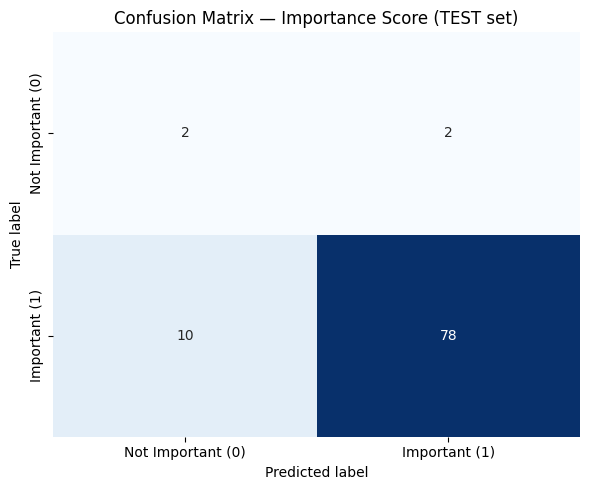

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Important (0)", "Important (1)"],
    yticklabels=["Not Important (0)", "Important (1)"],
    cbar=False
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — Importance Score (TEST set)")

plt.tight_layout()
plt.show()


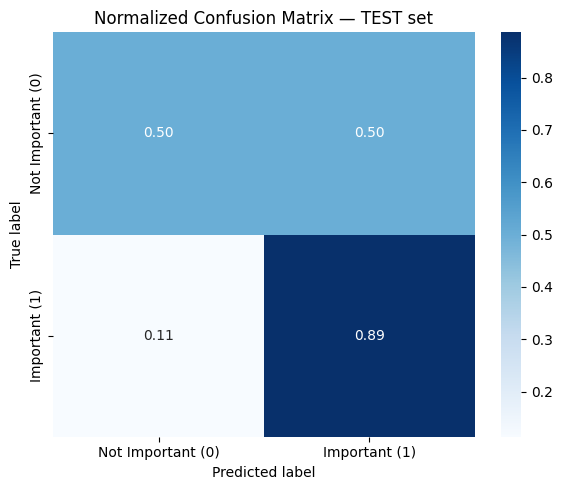

In [22]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["Not Important (0)", "Important (1)"],
    yticklabels=["Not Important (0)", "Important (1)"],
    cbar=True
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix — TEST set")

plt.tight_layout()
plt.show()


In [26]:
# 3) Core metrics (focus on class=1)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
)

tn, fp, fn, tp = cm.ravel()  # because it's 2x2 with labels [0,1]

acc = accuracy_score(y_true, y_pred)

p1, r1, f1_1, s1 = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=[1]
)
p1, r1, f1_1 = float(p1[0]), float(r1[0]), float(f1_1[0])

# macro / weighted f1 (good for diploma)
_, _, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
_, _, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")

# 4) Diploma-ready summary table
summary_df = pd.DataFrame(
    [
        {
            "Dataset": "TEST",
            "Accuracy": acc,
            "Precision (class=1)": p1,
            "Recall (class=1)": r1,
            "F1 (class=1)": f1_1,
            "F1 Macro": float(f1_macro),
            "F1 Weighted": float(f1_weighted),
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn),
        }
    ]
)

# 5) Full per-class table (0 and 1)
report = classification_report(y_true, y_pred, labels=[0,1], output_dict=True, zero_division=0)
per_class_df = pd.DataFrame(report).T.reset_index().rename(columns={"index": "Class/Avg"})

# Keep the rows in a sensible order
order = ["0", "1", "macro avg", "weighted avg"]
per_class_df["Class/Avg"] = per_class_df["Class/Avg"].astype(str)
per_class_df = per_class_df[per_class_df["Class/Avg"].isin(order)].copy()
per_class_df["Class/Avg"] = pd.Categorical(per_class_df["Class/Avg"], categories=order, ordered=True)
per_class_df = per_class_df.sort_values("Class/Avg")

# 6) Pretty formatting (works in Jupyter/Colab)
def pretty(df):
    return (
        df.style
        .format(precision=4)
        .set_caption("Importance Score — TEST Metrics")
        .set_table_styles([
            {"selector":"caption", "props":[("font-size","16px"), ("font-weight","600")]},
            {"selector":"th", "props":[("background-color","#f2f2f2"), ("font-weight","700")]},
            {"selector":"td", "props":[("padding","6px 10px")]},
        ])
    )

pretty(summary_df)

,Dataset,Accuracy,Precision (class=1),Recall (class=1),F1 (class=1),F1 Macro,F1 Weighted,TP,FP,FN,TN
0,TEST,0.8696,0.9750,0.8864,0.9286,0.5893,0.8991,78,2,10,2


In [27]:
pretty(per_class_df[["Class/Avg","precision","recall","f1-score","support"]].rename(
    columns={"f1-score":"f1", "Class/Avg":"Class"}
))


,Class,precision,recall,f1,support
0,0,0.1667,0.5000,0.2500,4.0000
1,1,0.9750,0.8864,0.9286,88.0000
3,macro avg,0.5708,0.6932,0.5893,92.0000
4,weighted avg,0.9399,0.8696,0.8991,92.0000


Interpretation of Importance Score Model (TEST set)

The importance scoring model demonstrates strong performance on identifying important segments (class 1), which is the primary objective of the task.

On the test set of 92 segments, the model achieves:

Precision (class 1): 0.975

Recall (class 1): 0.886

F1-score (class 1): 0.929

This indicates that when the model predicts a segment as important, it is almost always correct, and it successfully captures the majority of truly important segments.

The confusion matrix shows:

78 true positives (important segments correctly identified)

10 false negatives (important segments missed)

2 false positives (non-important segments incorrectly marked as important)

2 true negatives

From an application perspective, this behavior is desirable:
the model is conservative, prioritizing precision and avoiding false positives, which reduces noise for downstream summarization.

Class Imbalance Consideration

The dataset is highly imbalanced (88 important vs. 4 non-important segments in the test set). As a result:

Overall accuracy (86.96%) is not a reliable indicator of performance

Performance on class 0 is limited (F1 = 0.25), primarily due to very few negative samples

This limitation is reflected in the macro F1-score (0.589), which averages performance across classes equally.

However, because the system is explicitly designed to extract key information, performance on class 1 is the correct metric to optimize.

The importance scoring model achieves high precision and recall on important segments (F1 = 0.93), making it effective for identifying salient content in multi-speaker conversations, despite class imbalance.

Saving the model

In [15]:
trainer.save_model("/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_model")
tokenizer.save_pretrained("/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_model")


('/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_model/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_model/special_tokens_map.json',
 '/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_model/vocab.json',
 '/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_model/merges.txt',
 '/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_model/added_tokens.json',
 '/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_model/tokenizer.json')

In [16]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

path = "/content/drive/MyDrive/Colab Notebooks/NLP_final_project/data/importance_model"

tok = AutoTokenizer.from_pretrained(path)
mdl = AutoModelForSequenceClassification.from_pretrained(path)

print("Model and tokenizer loaded OK")


Model and tokenizer loaded OK


Requirements.txt:

python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
torch: 2.9.0+cpu
cuda available: False
transformers: 4.57.3
tokenizers: 0.22.1
datasets: 4.0.0
sklearn: 1.6.1
numpy: 2.0.2
pandas: 2.2.2
